<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_17644/3163346549.py:74: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi \\rangle$')
/home/alessandro/documents/adr_qft/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alessandro/documents/adr_qft/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


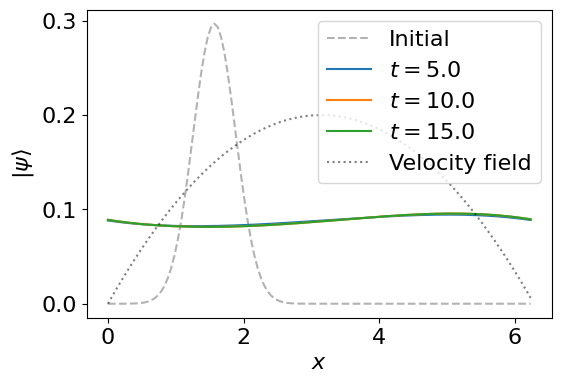

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# subroutine for QFT matrix (and its inverse) on n qubits
def get_qft_mat(n):
    num_states = 1<<n # this is 2**n
    omega = np.exp(-2j*np.pi/num_states)

    qft = np.zeros((num_states,num_states),dtype=complex)

    for i in range(num_states):
        for j in range(num_states):
            qft[i][j] = omega**(i*j)/np.sqrt(num_states)

    qft_inv = qft.transpose().conjugate()

    return qft, qft_inv

# parameters
n = 7 # number of qubits
N = 2**n # number of grid points
L = 2*np.pi # length of the box
dx = L/N # grid spacing
x = np.arange(N)*dx # grid points
times = np.arange(5, 16, 5)
D = 1.0 # diffusion coeff

#c = 0.1*np.sin(2*np.pi*x/L) + 0.2 # velocity field
#cx = 0.1*2*np.pi/L * np.cos(2*np.pi*x/L) # velocity field gradient
c_L = 0.0
c_H = 0.2
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x # velocity field
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L  # velocity field gradient

a = np.zeros_like(x)  # np.ones_like(x) 

# initial condition
sigma = L/20
state_i = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state_i = state_i / np.linalg.norm(state_i) # normalize the initial state

j_indices = np.arange(N)
k_j = 2*np.pi /L * np.where(j_indices < N/2, j_indices, j_indices - N)
P1 = np.diag(1j*k_j)
P2 = np.diag(-k_j**2)
QFT, QFT_inv = get_qft_mat(n)
D1 = QFT_inv @ P1 @ QFT
D2 = QFT_inv @ P2 @ QFT

A = - (D*D2-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c)) - 0.5*np.diag(cx)-np.diag(a))




plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (6, 4), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure()
plt.plot(x, state_i, 'k--', label='Initial', alpha=0.3)
for t in times:

    U = expm(-A*t)
    final_state = U @ state_i
    final_state = final_state / np.linalg.norm(final_state) # normalize the final state
    plt.plot(x, final_state, label=f'$t={t:.1f}$')

plt.plot(x,c, 'k:', label='Velocity field', alpha=0.5)
plt.xlabel('$x$')
plt.ylabel('$|\psi \\rangle$')
plt.legend()
plt.savefig(f'./figures/lchs_diff_adv_D{D:.2f}.pdf', bbox_inches='tight')
plt.show()

Trotter error analysis

Error in Trotterization: 1.73e-02
Error in Trotterization: 1.68e-03
Error in Trotterization: 1.24e-04
Error in Trotterization: 1.44e-06
Error in Trotterization: 1.45e-08
Error in Trotterization: 1.45e-10


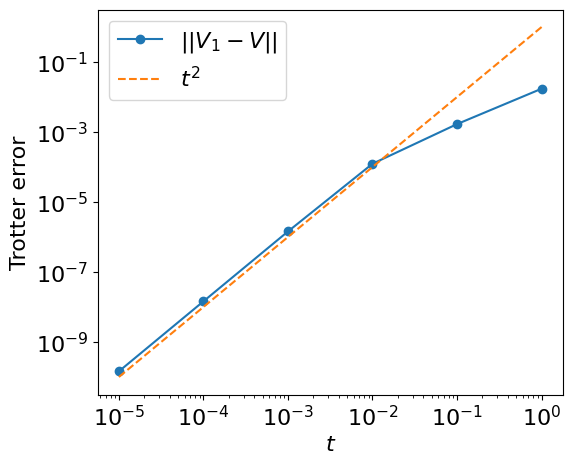

In [2]:
from numpy.linalg import matrix_power
powers = np.arange(0, 6, 1)
times = 0.1**powers
errs = []
errs2 = []
for t in times:
    omega = 1
    V = expm(1j*omega*t*(D*D2- 0.5*np.diag(cx)-np.diag(a)) -0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* t)

    r = 1000
    dt = t/r
    A_1  = expm(1j*omega*dt*(D*D2))
    A_2 = expm(1j*omega*dt*(- 0.5*np.diag(cx)-np.diag(a)))
    A_3 = expm(-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* dt)  


    A_11  = expm(1j*omega*dt/2*(D*D2))
    A_21 = expm(1j*omega*dt/2*(- 0.5*np.diag(cx)-np.diag(a)))
    A_31 = expm(-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* dt/2)  
    U_1 = matrix_power(A_1@A_2@A_3, r)
    U_2 = matrix_power(A_11@A_21@A_31@A_31@A_21@A_11, r)

    err = np.linalg.norm(U_1 - V)
    err2 = np.linalg.norm(U_2 - V)

    errs.append(err)
    errs2.append(err2)

    print(f"Error in Trotterization: {err:.2e}")


plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (6, 5), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure()
plt.ylabel('Trotter error')
plt.xlabel('$t$')
plt.loglog(times, errs, 'o-', label='$||V_1 - V||$')
#plt.loglog(times, errs2, 's-', label='$||U_2 - V||$')
plt.loglog(times, times**2, '--', label='$t^2$')
#plt.loglog(times, times**3, '--', label='$t^3$')
plt.legend(fontsize=16)
plt.savefig(f'./figures/trotter_error_1.pdf', bbox_inches='tight')
plt.show()


Error in Trotterization: 6.36e+00
Error in Trotterization: 1.94e-01
Error in Trotterization: 1.73e-02
Error in Trotterization: 1.73e-03
Error in Trotterization: 1.73e-04


<Figure size 600x500 with 0 Axes>

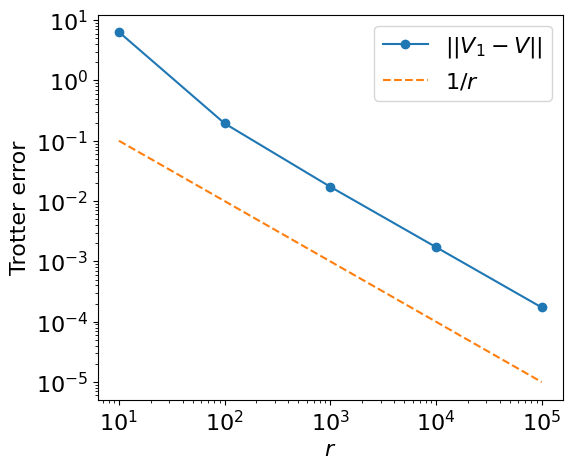

In [3]:
from numpy.linalg import matrix_power

t = 1
errs = []
powers = np.arange(1, 6, 1)
rs = 10**powers
for r in rs:
    omega = 1
    V = expm(1j*omega*t*(D*D2- 0.5*np.diag(cx)-np.diag(a)) -0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* t)
    dt = t/r
    A_1  = expm(1j*omega*dt*(D*D2))
    A_2 = expm(1j*omega*dt*(- 0.5*np.diag(cx)-np.diag(a)))
    A_3 = expm(-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* dt)  
    U_1 = matrix_power(A_1@A_2@A_3, r)
    err = np.linalg.norm(U_1 - V)
    errs.append(err)
    print(f"Error in Trotterization: {err:.2e}")
plt.figure()
plt.figure()
plt.ylabel('Trotter error')
plt.xlabel('$r$')
plt.loglog(rs, errs, 'o-', label='$||V_1 - V||$')
plt.loglog(rs, 1/np.array(rs), '--', label='$1/r$')
plt.legend()
plt.savefig(f'./figures/trotter_error_2.pdf', bbox_inches='tight')
plt.show()

Error in Trotterization: 1.29e+00
Error in Trotterization: 1.73e-02
Error in Trotterization: 1.73e-03
Error in Trotterization: 1.68e-04
Error in Trotterization: 1.24e-05
Error in Trotterization: 1.44e-07
Error in Trotterization: 1.45e-09
Error in Trotterization: 2.63e-11


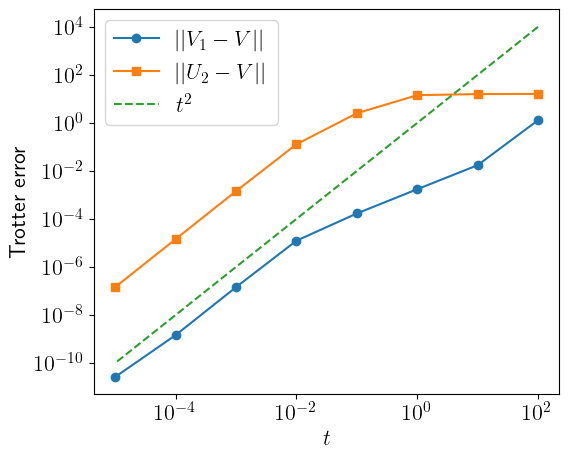

In [6]:
from numpy.linalg import matrix_power
powers = np.arange(-2, 6, 1)
times = 0.1**powers
errs = []
errs2 = []
for t in times:
    omega = 1
    V = expm(1j*omega*t*(D*D2- 0.5*np.diag(cx)-np.diag(a)) -0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* t)

    r = 10000
    dt = t/r
    A_1  = expm(1j*omega*dt*(D*D2))
    A_2 = expm(1j*omega*dt*(- 0.5*np.diag(cx)-np.diag(a)))
    A_3 = expm(-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* dt)  



    U_1 = matrix_power(A_1@A_2@A_3, r)

    A_11  = expm(1j*omega*t*(D*D2))
    A_22 = expm(1j*omega*t*(- 0.5*np.diag(cx)-np.diag(a)))
    A_33 = expm(-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c))* t) 
    U_2 = A_11@A_22@A_33

    err = np.linalg.norm(U_1 - V)
    err2 = np.linalg.norm(U_2 - V)

    errs.append(err)
    errs2.append(err2)

    print(f"Error in Trotterization: {err:.2e}")


plt.rcParams.update({
    "text.usetex": True,
    "font.size": 16,
    "font.weight": "bold",      # Bolds standard text
    "axes.labelweight": "bold", # Bolds axis labels
    "figure.figsize": (6, 5), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure()
plt.ylabel('Trotter error')
plt.xlabel('$t$')
plt.loglog(times, errs, 'o-', label='$||V_1 - V||$')
plt.loglog(times, errs2, 's-', label='$||U_2 - V||$')
plt.loglog(times, times**2, '--', label='$t^2$')
plt.legend(fontsize=16)
plt.savefig(f'./figures/trotter_error_test.pdf', bbox_inches='tight')
plt.show()
